# sfink37 Lesson 1 — Caro-Kann Defense Advance (as White)
**Priority #1 | 122 games | 39.3% win rate**

All statistics computed fresh from game files on every run.
Board diagrams are illustrative example lines, clearly labelled as such.

In [ ]:
import chess
import chess.pgn
import chess.svg
import json
import glob
import io
import re
from collections import Counter, defaultdict
from IPython.display import display, HTML
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── config ────────────────────────────────────────────────────────────────────
USERNAME     = 'sfink37'
GAMES_DIR    = 'games_sf'
TIME_CLASSES = {'bullet', 'blitz'}
ECO_KEYWORDS = ['Caro', 'Advance']   # all must appear in ECOUrl
BOARD_SIZE   = 380
# ─────────────────────────────────────────────────────────────────────────────

def load_games(username, games_dir, time_classes, eco_keywords):
    files = sorted(glob.glob(f'{games_dir}/*.json'))
    games = []
    for f in files:
        with open(f, encoding='utf-8') as fh:
            month = json.load(fh)
        for g in month:
            if g.get('time_class') not in time_classes: continue
            white = g.get('white', {})
            if white.get('username', '').lower() != username.lower(): continue
            result = white.get('result', '')
            if   result == 'win': outcome = 'win'
            elif result in ('checkmated','timeout','resigned','lose','abandoned'): outcome = 'loss'
            elif result in ('agreed','stalemate','repetition','insufficient','timevsinsufficient','50move'): outcome = 'draw'
            else: continue
            pgn_str = g.get('pgn', '')
            m = re.search(r'\[ECOUrl "([^"]+)"\]', pgn_str)
            eco = m.group(1) if m else ''
            if not all(kw in eco for kw in eco_keywords): continue
            games.append({'outcome': outcome, 'pgn': pgn_str, 'eco': eco})
    return games

def board_after(moves_san):
    board = chess.Board()
    for san in moves_san:
        board.push_san(san)
    return board

def show_board(board, arrows=None, caption='', size=BOARD_SIZE):
    # Embed SVG directly as HTML — survives nbconvert export correctly
    svg = chess.svg.board(board, arrows=arrows or [], size=size)
    html = svg
    if caption:
        html = (
            f'<p style="font-family:monospace;font-size:13px;'
            f'margin:4px 0 8px 0;color:#555">{caption}</p>'
        ) + html
    display(HTML(html))

## Step 1 — Load games (filtered by ECO_KEYWORDS)

In [100]:
games  = load_games(USERNAME, GAMES_DIR, TIME_CLASSES, ECO_KEYWORDS)
counts = Counter(g['outcome'] for g in games)
total  = len(games)
wr     = 100 * counts['win'] / total if total else 0

label = ' + '.join(ECO_KEYWORDS)
print(f'{label} games as white: {total}')
print(f'W:{counts["win"]}  L:{counts["loss"]}  D:{counts["draw"]}  Win%: {wr:.1f}%')

Caro + Advance games as white: 122
W:48  L:65  D:9  Win%: 39.3%


## Step 2 — Find critical junctions from actual game data

In [101]:
# Build a move tree: at each position white reaches, track which move was played and the outcome
move_tree = defaultdict(lambda: defaultdict(Counter))

for g in games:
    try:
        game  = chess.pgn.read_game(io.StringIO(g['pgn']))
        board = game.board()
        moves = list(game.mainline_moves())
        for i, move in enumerate(moves[:20]):
            if i % 2 == 0:  # white's move
                pos_key = board.fen().split(' ')[0]
                move_tree[pos_key][board.san(move)][g['outcome']] += 1
            board.push(move)
    except Exception:
        pass

# Find positions where move choice has a meaningful impact
junctions = []
for pos_key, moves_dict in move_tree.items():
    total_pos = sum(sum(v.values()) for v in moves_dict.values())
    if total_pos < 8: continue
    stats = []
    for san, c in moves_dict.items():
        t = sum(c.values())
        if t < 3: continue
        stats.append((san, t, round(100 * c['win'] / t, 1), c))
    if len(stats) < 2: continue
    wrs = [s[2] for s in stats]
    if max(wrs) - min(wrs) < 15: continue
    junctions.append((total_pos, pos_key, stats))

junctions.sort(reverse=True)
print(f'Critical junctions found: {len(junctions)}')
print()
for total_pos, pos_key, stats in junctions[:5]:
    print(f'Position (seen {total_pos}x):')
    for san, t, wr, c in sorted(stats, key=lambda x: -x[2]):
        tag = '  <-- GOOD' if wr == max(s[2] for s in stats) else '  <-- BAD' if wr == min(s[2] for s in stats) else ''
        print(f'  {san:8s} {t:3d}g  {wr:.1f}%  W:{c["win"]} L:{c["loss"]}{tag}')
    print()

Critical junctions found: 5

Position (seen 122x):
  Nf3        3g  66.7%  W:2 L:1  <-- GOOD
  d4       119g  38.7%  W:46 L:64  <-- BAD

Position (seen 71x):
  c3        40g  47.5%  W:19 L:19  <-- GOOD
  Bd3       23g  43.5%  W:10 L:11
  Nf3        6g  16.7%  W:1 L:5  <-- BAD

Position (seen 35x):
  Bd3       16g  50.0%  W:8 L:7  <-- GOOD
  a3         4g  50.0%  W:2 L:2  <-- GOOD
  b4        10g  30.0%  W:3 L:6  <-- BAD

Position (seen 20x):
  Be2       12g  41.7%  W:5 L:7  <-- GOOD
  Be3        5g  0.0%  W:0 L:3  <-- BAD

Position (seen 18x):
  a3         5g  60.0%  W:3 L:2  <-- GOOD
  Nf3        5g  60.0%  W:3 L:1  <-- GOOD
  c3         5g  0.0%  W:0 L:4  <-- BAD



## Step 2b — Stockfish centipawn evaluation at junction positions

Each move at each junction is evaluated at depth 16. The delta column shows centipawns lost vs the best move at that position — validates whether the win-rate signal reflects objective quality or sample noise.

In [102]:
import asyncio
import chess.engine

asyncio.set_event_loop_policy(asyncio.WindowsProactorEventLoopPolicy())

STOCKFISH_PATH   = r'E:\Github\Chesslatro\chesslatro\stockfish\stockfish.exe'
SF_DEPTH         = 16
CP_TOLERANCE     = 20   # best win-rate move must be within 20cp of SF best
MIN_QUAL_GAMES   = 15   # minimum total games across qualifying moves

junction_sf_evals = {}

with chess.engine.SimpleEngine.popen_uci(STOCKFISH_PATH) as engine:
    for total_pos, pos_key, stats in junctions:
        junction_sf_evals[pos_key] = {}
        try:
            board = chess.Board(pos_key + ' w KQkq - 0 1')
        except Exception:
            continue
        for san, t, wr, c in stats:
            try:
                b = board.copy()
                b.push(board.parse_san(san))
                info = engine.analyse(b, chess.engine.Limit(depth=SF_DEPTH))
                junction_sf_evals[pos_key][san] = info['score'].white().score(mate_score=1000)
            except Exception:
                pass

# Filter junctions — both signals must agree before we use a position as a lesson
consistent_junctions = []
print(f'Stockfish done: {len(junction_sf_evals)} positions at depth {SF_DEPTH}')
print(f'Filtering {len(junctions)} junctions  (CP_TOLERANCE={CP_TOLERANCE}, MIN_QUAL_GAMES={MIN_QUAL_GAMES})\n')

for tp, pk, stats in junctions:
    cp_map      = junction_sf_evals.get(pk, {})
    best_cp     = max(cp_map.values()) if cp_map else None
    qual_games  = sum(s[1] for s in stats)
    best_wr_san = max(stats, key=lambda x: x[2])[0]
    best_wr_val = max(stats, key=lambda x: x[2])[2]
    move_cp     = cp_map.get(best_wr_san)

    if qual_games < MIN_QUAL_GAMES:
        reason = f'too few games ({qual_games} < {MIN_QUAL_GAMES})'
    elif best_cp is not None and move_cp is not None and (best_cp - move_cp) > CP_TOLERANCE:
        delta = best_cp - move_cp
        reason = f'SF contradicts data — {best_wr_san} ({best_wr_val:.0f}% win) is -{delta}cp vs SF best'
    else:
        reason = None

    if reason:
        print(f'  SKIP (seen {tp:3d}x): {reason}')
    else:
        consistent_junctions.append((tp, pk, stats))
        sf_str = f'  sf_delta={best_cp - move_cp:+d}cp' if (best_cp is not None and move_cp is not None) else ''
        print(f'  KEEP (seen {tp:3d}x): {best_wr_san} leads at {best_wr_val:.0f}% win{sf_str}')

print(f'\nConsistent junctions kept: {len(consistent_junctions)} / {len(junctions)}')

Stockfish done: 5 positions at depth 16
Filtering 5 junctions  (CP_TOLERANCE=20, MIN_QUAL_GAMES=15)

  SKIP (seen 122x): SF contradicts data — Nf3 (67% win) is -31cp vs SF best
  KEEP (seen  71x): c3 leads at 48% win  sf_delta=+7cp
  KEEP (seen  35x): Bd3 leads at 50% win  sf_delta=+0cp
  KEEP (seen  20x): Be2 leads at 42% win  sf_delta=+13cp
  KEEP (seen  18x): a3 leads at 60% win  sf_delta=+5cp

Consistent junctions kept: 4 / 5


## Step 3 — Junction analysis (chart → board → table per junction)

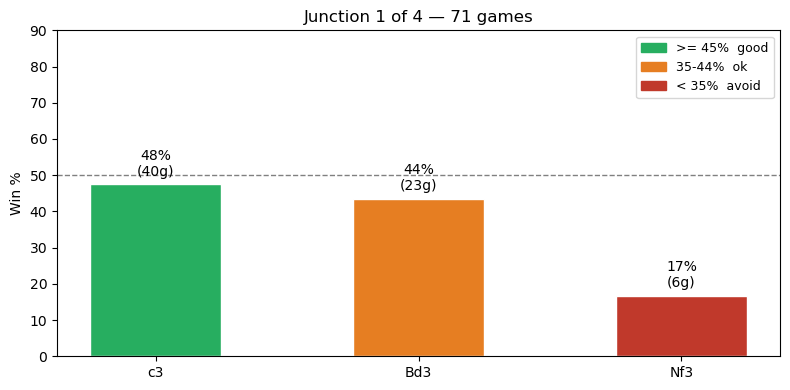

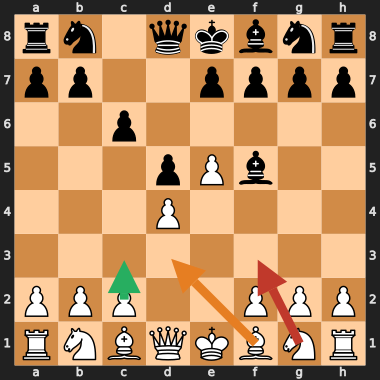


  Route to junction — most common line:
  #     White        Black
  ──────────────────────────────
  1     e4           c6
  2     d4           d5
  3     e5           Bf5
  --> white to move

  Move       Win%   SF delta  Record
  ──────────────────────────────────────────────
  c3          48%       -7cp  40g W:19 L:19 D:2  [GOOD]
  Bd3         44%      -23cp  23g W:10 L:11 D:2  [OK]
  Nf3         17%       +0cp  6g W:1 L:5 D:0  [AVOID]



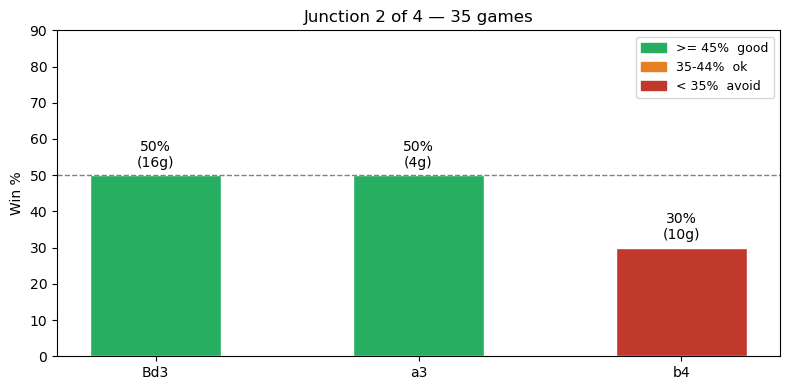

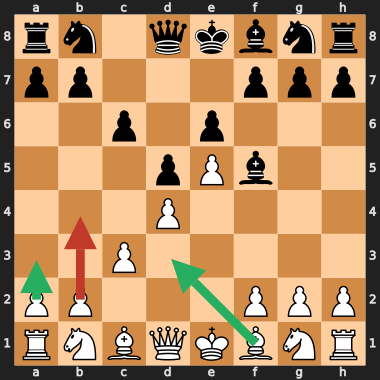


  Route to junction — most common line:
  #     White        Black
  ──────────────────────────────
  1     e4           c6
  2     d4           d5
  3     e5           Bf5
  4     c3           e6
  --> white to move

  Move       Win%   SF delta  Record
  ──────────────────────────────────────────────
  Bd3         50%       +0cp  16g W:8 L:7 D:1  [GOOD]
  a3          50%      -26cp  4g W:2 L:2 D:0  [GOOD]
  b4          30%      -25cp  10g W:3 L:6 D:1  [AVOID]



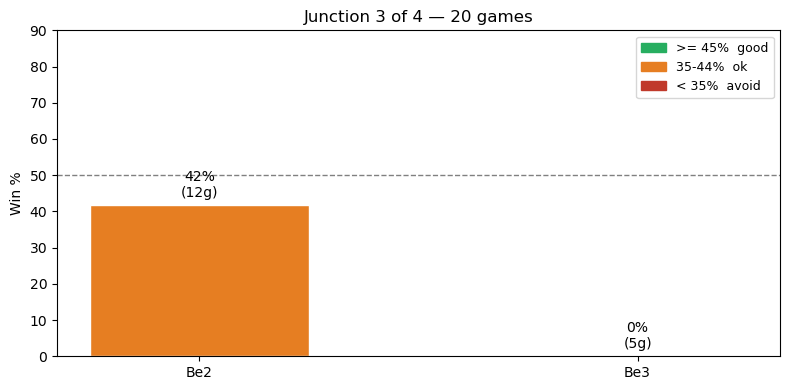

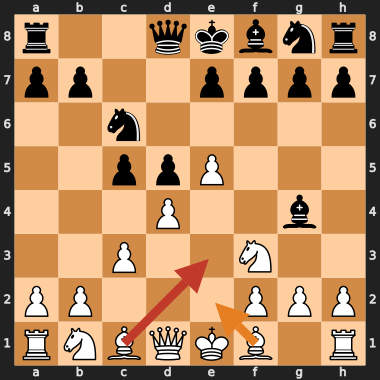

In [ ]:
def most_common_sequence(games, pos_key):
    """Replay actual games to find the most common move sequence reaching pos_key."""
    sequences = Counter()
    for g in games:
        try:
            game  = chess.pgn.read_game(io.StringIO(g['pgn']))
            board = game.board()
            played = []
            for move in game.mainline_moves():
                played.append(board.san(move))
                board.push(move)
                if board.fen().split(' ')[0] == pos_key:
                    sequences[tuple(played)] += 1
                    break
        except Exception:
            pass
    return list(sequences.most_common(1)[0][0]) if sequences else []


for idx, (jt, jfen, jstats) in enumerate(consistent_junctions):
    jstats_sorted = sorted(jstats, key=lambda x: -x[2])
    labels  = [s[0] for s in jstats_sorted]
    wrs     = [s[2] for s in jstats_sorted]
    ns      = [s[1] for s in jstats_sorted]
    colors  = ['#27ae60' if wr >= 45 else '#c0392b' if wr < 35 else '#e67e22' for wr in wrs]
    jcp     = junction_sf_evals.get(jfen, {})
    best_cp = max(jcp.values()) if jcp else None

    # Bar chart
    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.bar(labels, wrs, color=colors, width=0.5, edgecolor='white')
    ax.axhline(50, color='gray', linestyle='--', linewidth=1)
    ax.set_ylabel('Win %')
    ax.set_title(f'Junction {idx + 1} of {len(consistent_junctions)} — {jt} games')
    ax.set_ylim(0, 90)
    for bar, wr_val, n in zip(bars, wrs, ns):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                f'{wr_val:.0f}%\n({n}g)', ha='center', va='bottom', fontsize=10)
    green_patch  = mpatches.Patch(color='#27ae60', label='>= 45%  good')
    orange_patch = mpatches.Patch(color='#e67e22', label='35-44%  ok')
    red_patch    = mpatches.Patch(color='#c0392b', label='< 35%  avoid')
    ax.legend(handles=[green_patch, orange_patch, red_patch], loc='upper right', fontsize=9)
    plt.tight_layout()
    plt.show()

    # Board with colored arrows for every candidate move
    jboard = chess.Board(jfen + ' w KQkq - 0 1')
    arrows = []
    for san, t, wr, c in jstats_sorted:
        col      = '#27ae60' if wr >= 45 else '#c0392b' if wr < 35 else '#e67e22'
        move_obj = jboard.parse_san(san)
        arrows.append(chess.svg.Arrow(move_obj.from_square, move_obj.to_square, color=col))
    show_board(jboard, arrows=arrows,
               caption=f'Junction {idx + 1} ({jt} games) — green good | orange ok | red avoid')

    # Move sequence leading here (replayed from actual games)
    seq = most_common_sequence(games, jfen)
    if seq:
        print(f'\n  Route to junction — most common line:')
        print(f'  {"#":<5} {"White":<12} Black')
        print('  ' + '─' * 30)
        for i in range(0, len(seq), 2):
            move_num   = i // 2 + 1
            white_move = seq[i]
            black_move = seq[i + 1] if i + 1 < len(seq) else ''
            print(f'  {move_num:<5} {white_move:<12} {black_move}')
        print('  --> white to move')

    # Stats table
    print(f'\n  {"Move":<8} {"Win%":>6}  {"SF delta":>9}  Record')
    print('  ' + '─' * 46)
    for san, t, wr, c in jstats_sorted:
        cp    = jcp.get(san)
        delta = (cp - best_cp) if (cp is not None and best_cp is not None) else None
        ds    = f'{delta:+d}cp' if delta is not None else '—'
        tag   = '  [GOOD]' if wr >= 45 else '  [AVOID]' if wr < 35 else '  [OK]'
        print(f'  {san:<8} {wr:>5.0f}%  {ds:>9}  {t}g W:{c["win"]} L:{c["loss"]} D:{c.get("draw",0)}{tag}')
    print()